In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

sdi_data = pd.read_csv('./data/clean/sdi_cleaned_data.csv', index_col=0, parse_dates=True)
sdi_data

,sdi_A,sdi_B
date,,
2024-02-01,NaN,NaN
2024-02-02,NaN,NaN
2024-02-03,NaN,NaN
2024-02-04,NaN,NaN
2024-02-05,NaN,NaN
...,...,...
2025-01-27,1.5,1.47
2025-01-28,1.5,1.47
2025-01-29,NaN,NaN


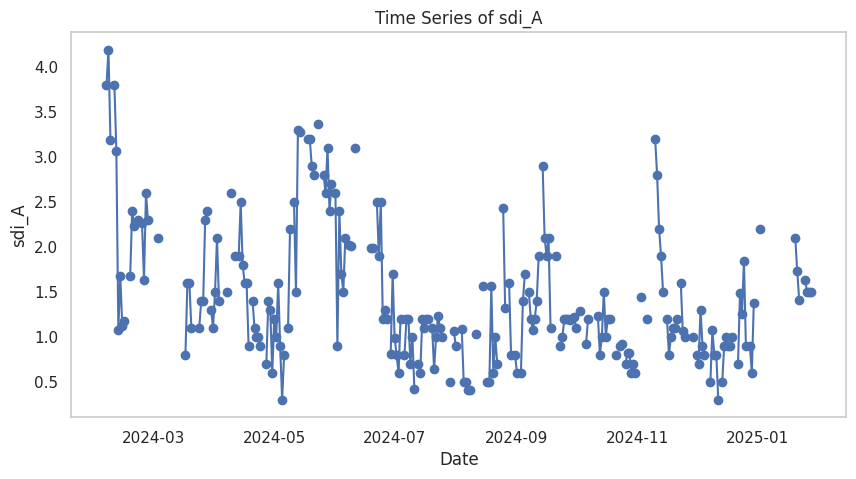

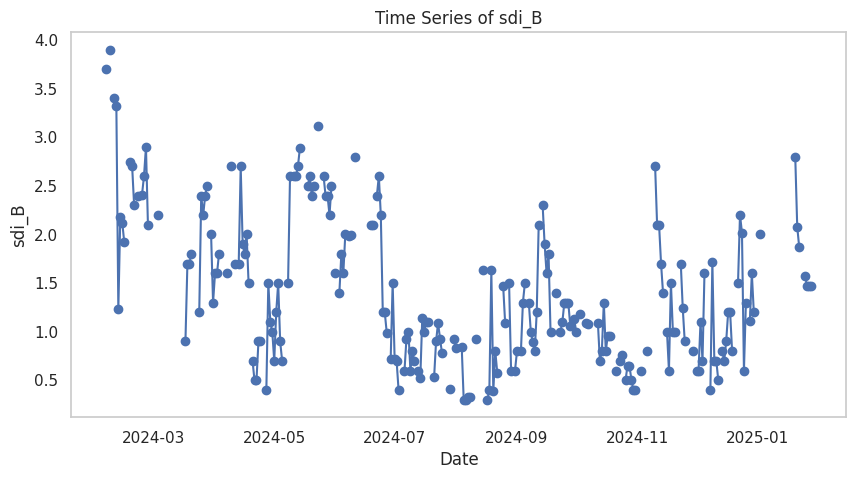

In [33]:
# time evolution of the two values
import matplotlib.pyplot as plt
for col in sdi_data.columns:
    if col != 'DATE':
        plt.figure(figsize=(10, 5))
        plt.plot(sdi_data.index, sdi_data[col], marker='o')
        plt.title(f'Time Series of {col}')
        plt.xlabel('Date')
        plt.ylabel(col)
        plt.grid()
        plt.show()


In [ ]:
# load the physical chemical data:
import pandas as pd
import numpy as np

# read the necessary data
rawdata = pd.read_csv('./data/clean/clean_data.csv')
# convert the date column to datetime format
# format="mixed" parses each value independently (the column mixes dd/mm/yyyy and
# dd/mm/yy, e.g. some days in Oct-Dec 2024 use a 2-digit year); inferring a single
# format for the whole column would silently coerce mismatched rows to NaT and drop
# them in the groupby below.
rawdata["DATE"] = pd.to_datetime(rawdata["DATE"], format="mixed", dayfirst=True, errors='coerce')
# turn all column into numeric, except the date  and heure columns
for col in rawdata.columns:
    if col not in ['DATE', 'HEURE']:
        rawdata[col] = pd.to_numeric(rawdata[col], errors='coerce')

# replace Heure values by categories
# 8h00 is the morning, 10h30 or 10h00 is midday, 14h00 or 15h30 is the afternoon.
def categorize_heure(heure):
    if pd.isna(heure):
        return np.nan
    else:
        heure = str(heure).strip()  # Remove any leading/trailing whitespace
        if heure in ['8h00', '8h30']:
            return 'morning'
        elif heure in ['10h00', '10h30']:
            return 'midday'
        elif heure in ['14h00', '15h00', '15h30']:
            return 'afternoon'
        else:
            return 'unknown'
rawdata['HEURE'] = rawdata['HEURE'].apply(categorize_heure)

# avergae the values of the same day
avgdata = rawdata.drop(columns=['HEURE']).groupby('DATE').mean().reset_index()


In [35]:
# set the data as index 
avgdata.set_index('DATE', inplace=True)
avgdata

,pH_BC,Température_BC,Conductivité_BC,TDS_BC,Turbidité_BC,Ph_O_DE_A,Température_O_DE_A,Conductivité_O_DE_A,TDS_O_DE_A,Turbidité_O_DE_A,...,Température_O_RO,Conductivité_O_RO,TDS_O_RO,Turbidité_O_RO,Ph_O_EX,Température_O_EX,Conductivité_O_EX,TDS_O_EX,Chlore libre_O_EX,Turbidité_O_EX
DATE,,,,,,,,,,,,,,,,,,,,,
2024-01-01,8.260000,16.833333,55.033333,33.020000,0.403333,8.210000,16.966667,55.033333,33.02,0.116667,...,18.033333,243.000000,121.500000,0.01,7.040000,18.800000,289.000000,144.500000,1.10,0.010000
2024-01-02,8.246667,16.300000,55.000000,33.000000,0.973333,8.200000,16.533333,55.000000,33.00,0.350000,...,NaN,NaN,NaN,NaN,6.973333,18.266667,285.333333,142.666667,1.00,0.010000
2024-01-03,8.226667,17.066667,54.700000,32.820000,0.930000,8.163333,17.500000,54.833333,32.90,0.213333,...,17.450000,214.800000,107.400000,0.01,6.943333,18.300000,267.666667,133.500000,1.00,0.010000
2024-01-04,8.206667,16.933333,54.933333,32.960000,0.326667,8.186667,16.500000,55.066667,33.04,0.276667,...,17.000000,216.766667,108.383333,0.01,7.020000,17.466667,317.666667,158.833333,1.00,0.010000
2024-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-27,8.140000,17.933333,55.566667,38.896667,0.370000,8.106667,17.066667,NaN,NaN,0.716667,...,17.066667,281.666667,154.916667,0.00,8.213333,17.266667,448.333333,246.583333,1.00,0.140000
2025-01-28,8.203333,18.000000,55.500000,38.850000,2.596667,8.163333,17.133333,NaN,NaN,1.620000,...,17.400000,275.333333,151.433333,0.00,8.310000,17.366667,395.000000,217.250000,1.00,0.033333
2025-01-29,8.170000,17.200000,NaN,NaN,0.620000,8.120000,16.510000,NaN,NaN,1.110000,...,16.800000,280.000000,154.000000,0.00,8.440000,17.700000,417.000000,229.350000,1.00,0.000000


In [39]:
# merge the two dataframes on the index
merged_df = sdi_data.merge(avgdata, left_index=True, right_index=True, how='left')
merged_df

,sdi_A,sdi_B,pH_BC,Température_BC,Conductivité_BC,TDS_BC,Turbidité_BC,Ph_O_DE_A,Température_O_DE_A,Conductivité_O_DE_A,...,Température_O_RO,Conductivité_O_RO,TDS_O_RO,Turbidité_O_RO,Ph_O_EX,Température_O_EX,Conductivité_O_EX,TDS_O_EX,Chlore libre_O_EX,Turbidité_O_EX
date,,,,,,,,,,,,,,,,,,,,,
2024-02-01,NaN,NaN,8.060000,17.366667,55.100000,33.060000,0.780000,8.036667,17.100000,55.066667,...,17.500000,209.666667,104.833333,0.0,6.876667,17.666667,271.666667,135.833333,0.980,0.000000
2024-02-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-02-03,NaN,NaN,8.120000,16.866667,55.033333,33.020000,0.650000,8.106667,16.966667,54.933333,...,17.333333,200.266667,100.133333,0.0,6.856667,17.666667,270.000000,135.000000,0.960,0.000000
2024-02-04,NaN,NaN,8.063333,17.066667,54.966667,32.980000,0.413333,8.060000,16.933333,54.933333,...,16.966667,193.466667,96.750000,0.0,6.796667,17.100000,265.666667,132.833333,1.035,0.000000
2024-02-05,NaN,NaN,8.113333,16.733333,55.333333,33.200000,0.440000,8.096667,16.800000,55.333333,...,16.766667,190.500000,95.250000,0.0,6.906667,17.233333,272.666667,136.333333,0.940,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-27,1.5,1.47,8.140000,17.933333,55.566667,38.896667,0.370000,8.106667,17.066667,NaN,...,17.066667,281.666667,154.916667,0.0,8.213333,17.266667,448.333333,246.583333,1.000,0.140000
2025-01-28,1.5,1.47,8.203333,18.000000,55.500000,38.850000,2.596667,8.163333,17.133333,NaN,...,17.400000,275.333333,151.433333,0.0,8.310000,17.366667,395.000000,217.250000,1.000,0.033333
2025-01-29,NaN,NaN,8.170000,17.200000,NaN,NaN,0.620000,8.120000,16.510000,NaN,...,16.800000,280.000000,154.000000,0.0,8.440000,17.700000,417.000000,229.350000,1.000,0.000000


## Correlation matrix

Number of rows in the merged dataframe: 190


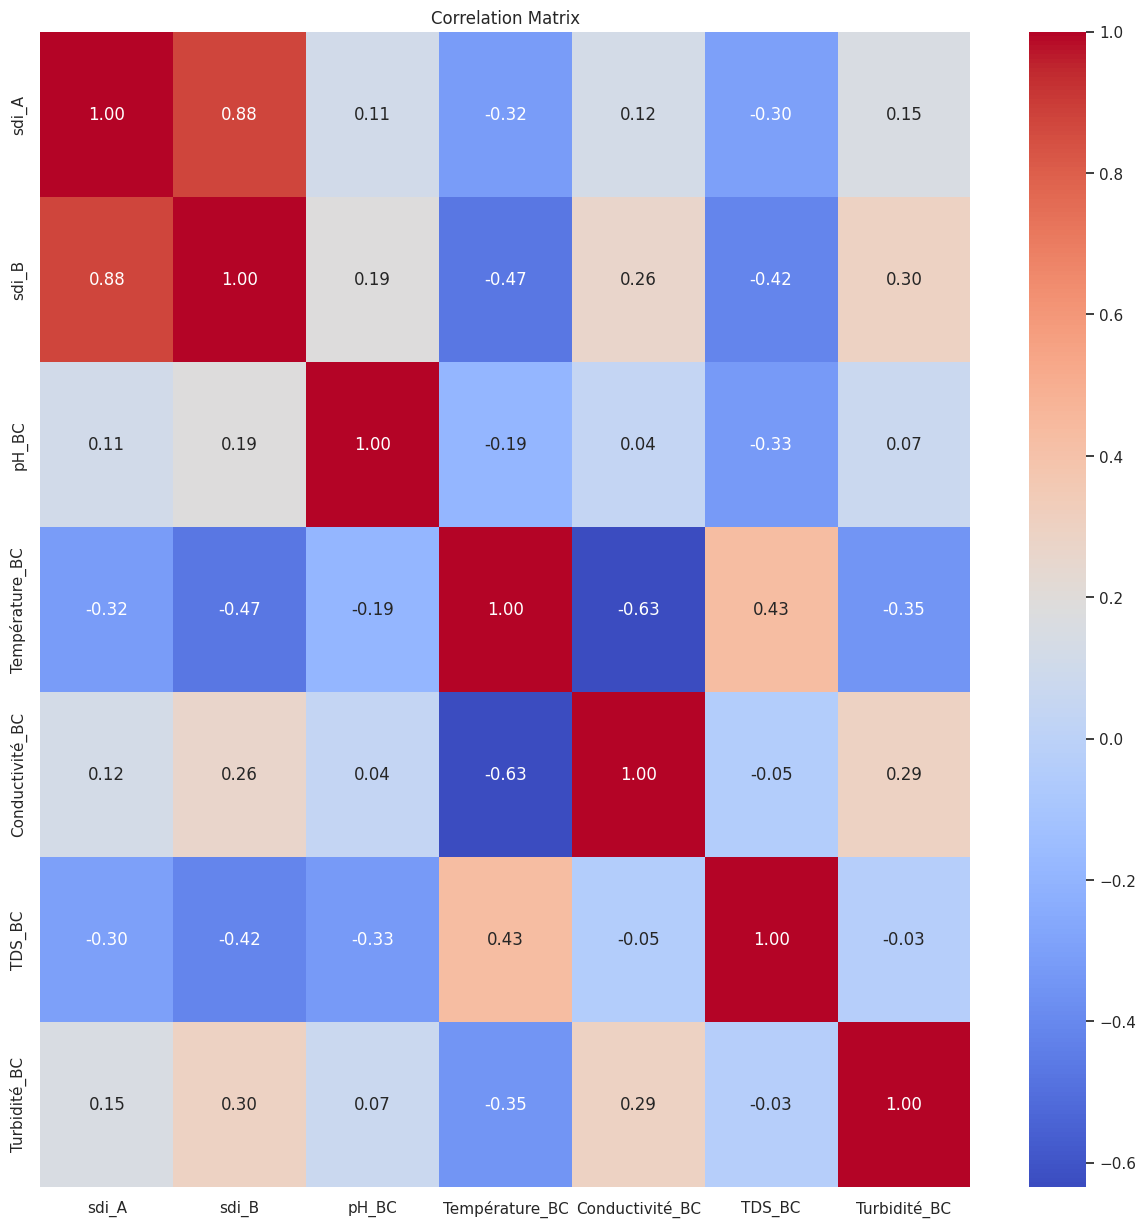

In [40]:
# select only sdi column and the column that include BC in their name
sdi_bc_df = merged_df[['sdi_A', 'sdi_B'] + [col for col in merged_df.columns if 'BC' in col]]
print("Number of rows in the merged dataframe:", len(sdi_bc_df.dropna()))
corr_matrix = sdi_bc_df.corr()
plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')

plt.show()

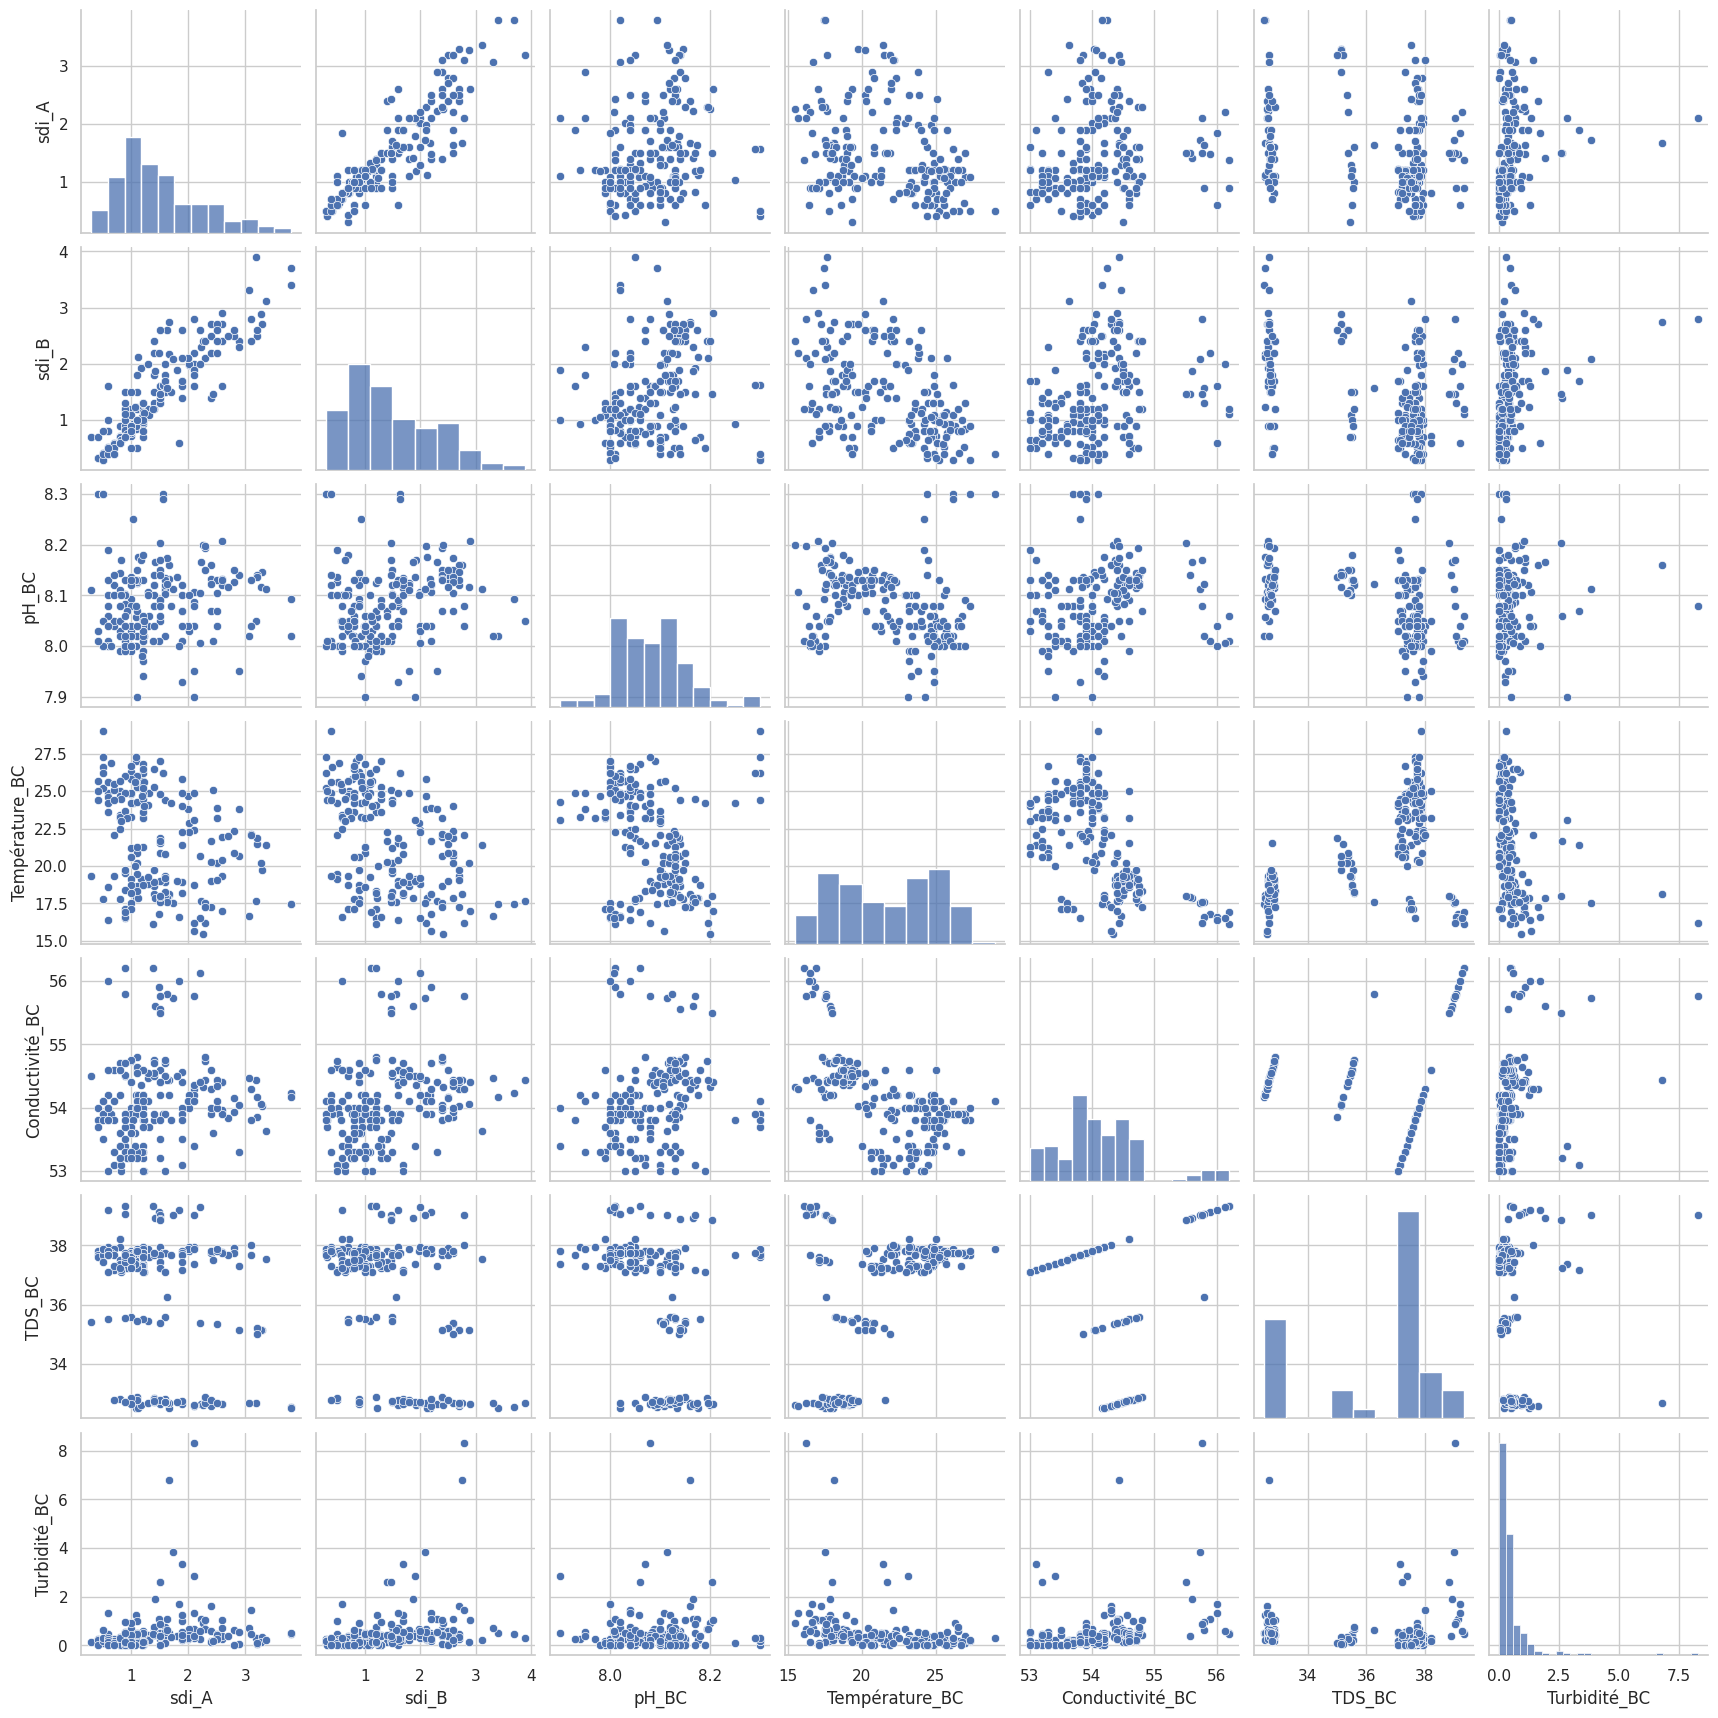

In [41]:
import seaborn as sns

sns.pairplot(sdi_bc_df.dropna())

Number of rows in the merged dataframe: 2


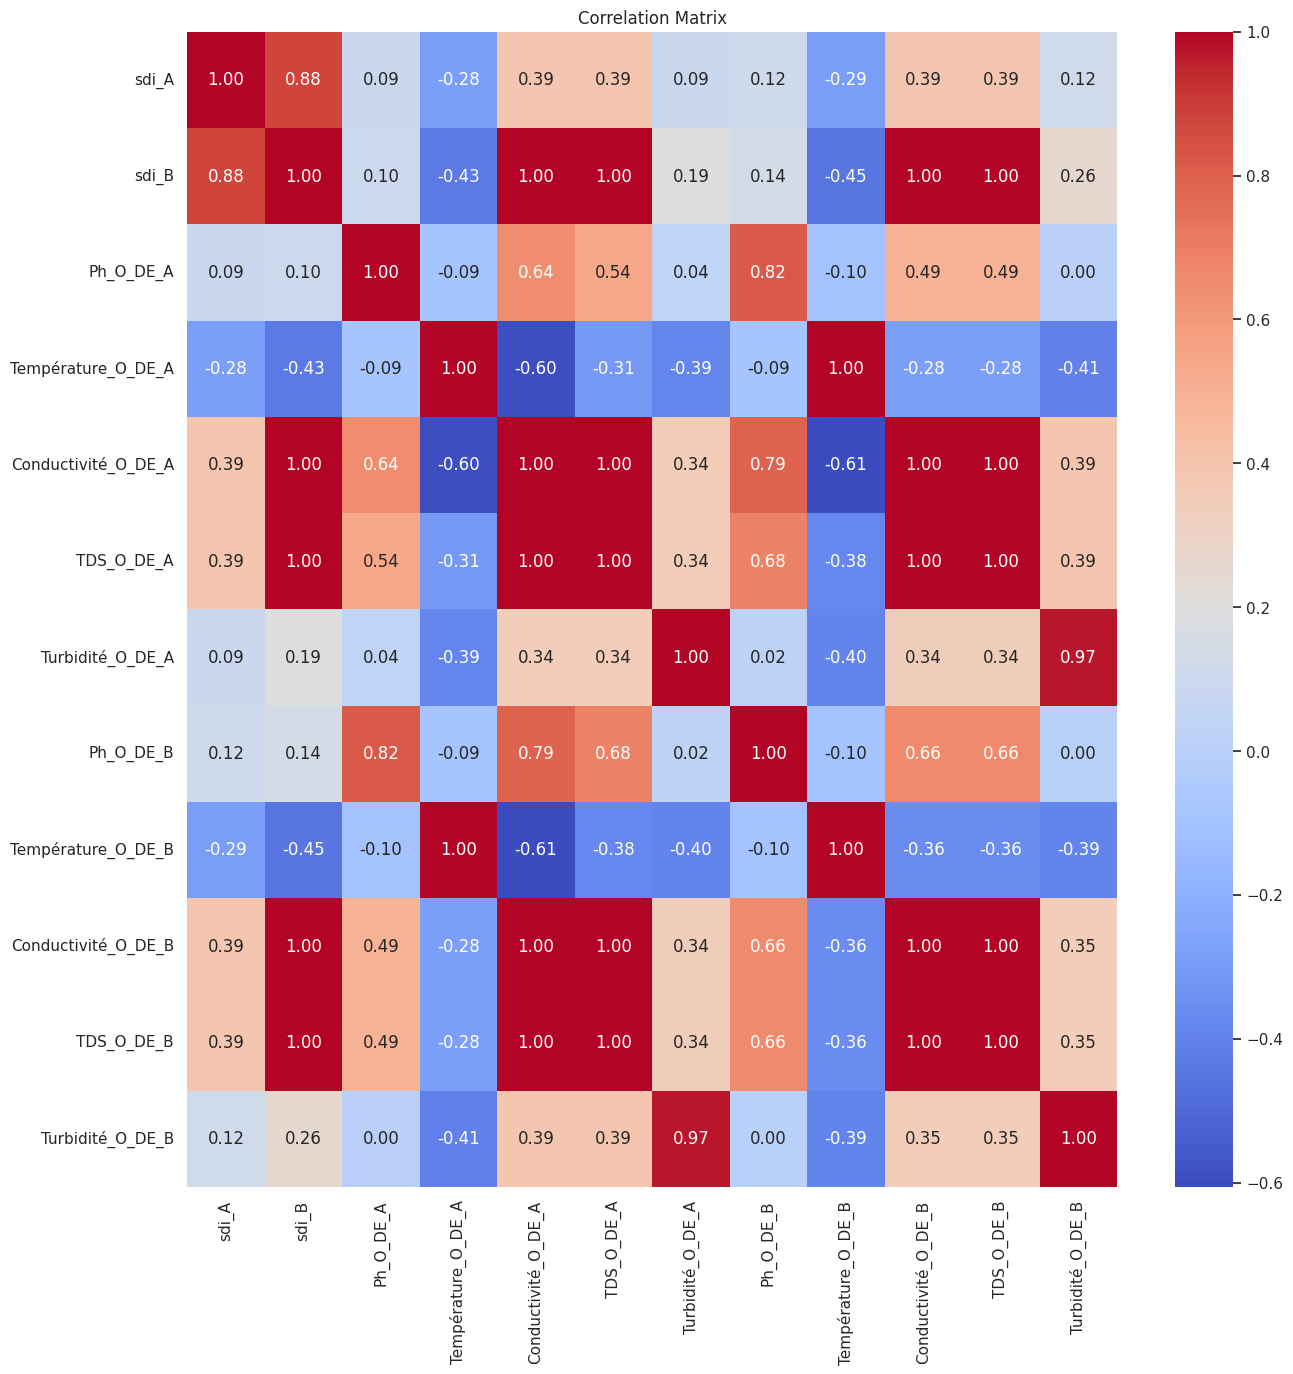

In [42]:
# select only sdi column and the column that include BC in their name
sdi_de_df = merged_df[['sdi_A', 'sdi_B'] + [col for col in merged_df.columns if 'DE' in col]]
print("Number of rows in the merged dataframe:", len(sdi_de_df.dropna()))
corr_matrix = sdi_de_df.corr()
plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')

plt.show()

Number of rows in the merged dataframe: 2


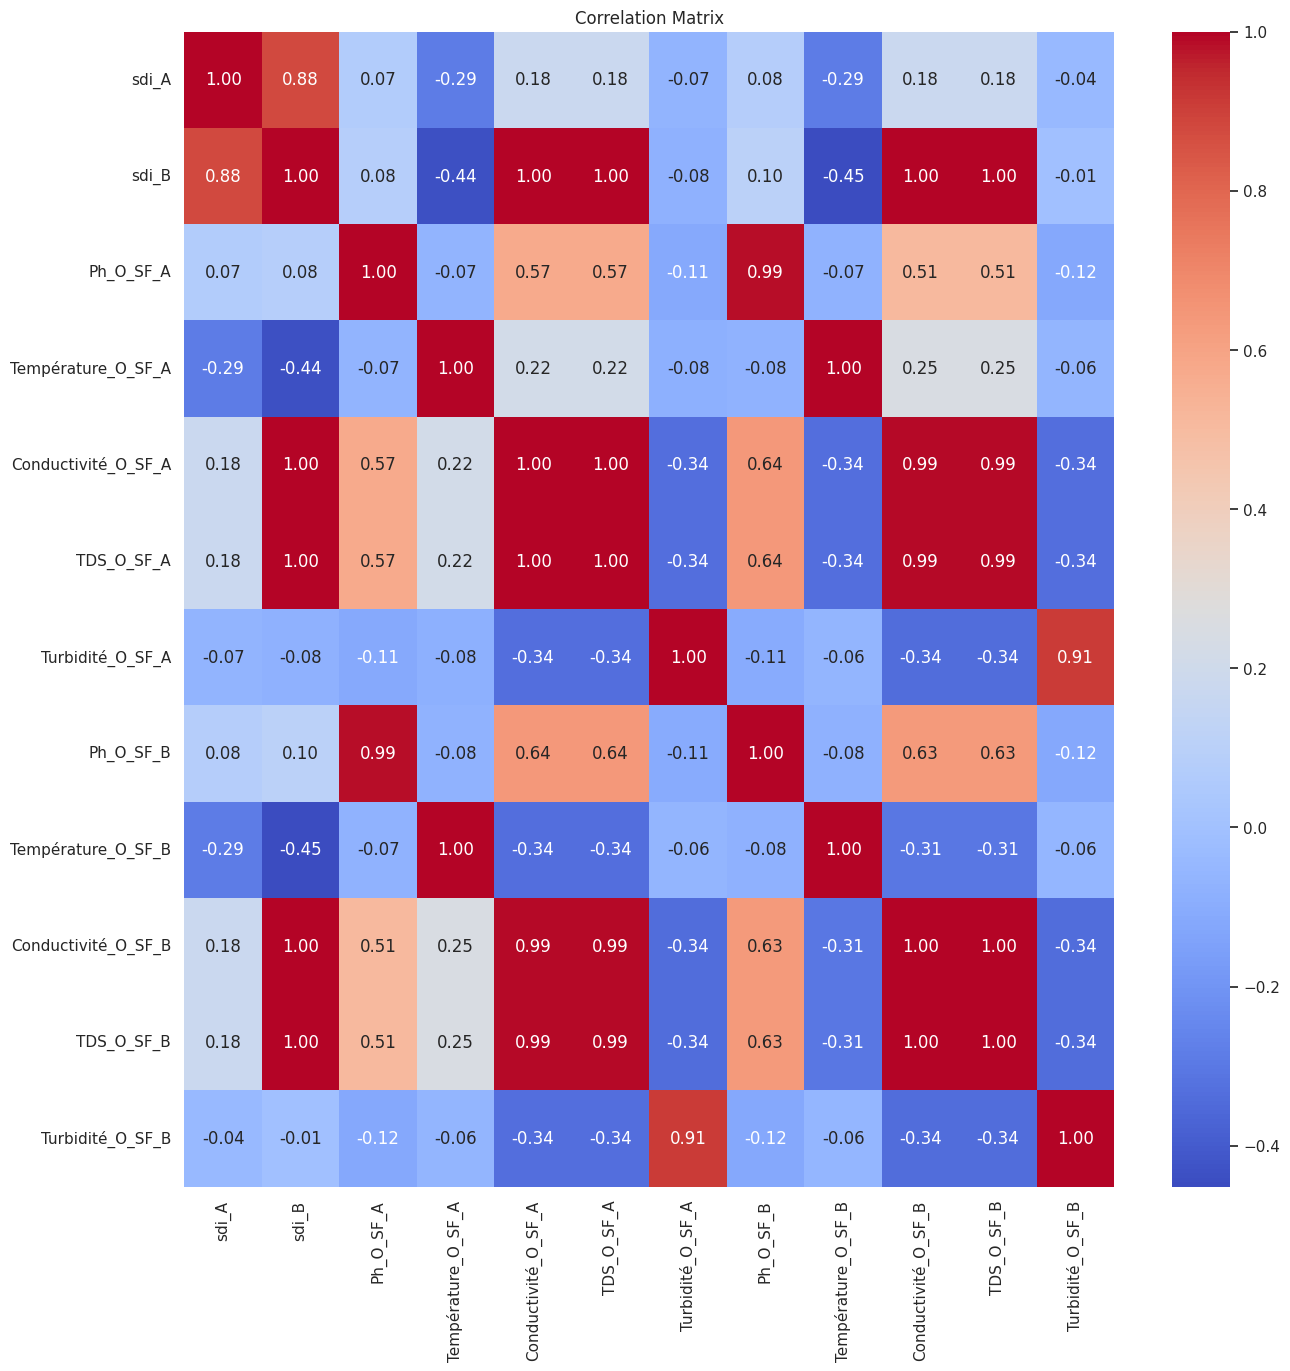

In [43]:
# select only sdi column and the column that include SF in their name
sdi_sf_df = merged_df[['sdi_A', 'sdi_B'] + [col for col in merged_df.columns if 'SF' in col]]
print("Number of rows in the merged dataframe:", len(sdi_sf_df.dropna()))
corr_matrix = sdi_sf_df.corr()
plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')

plt.show()

Number of rows in the merged dataframe: 190


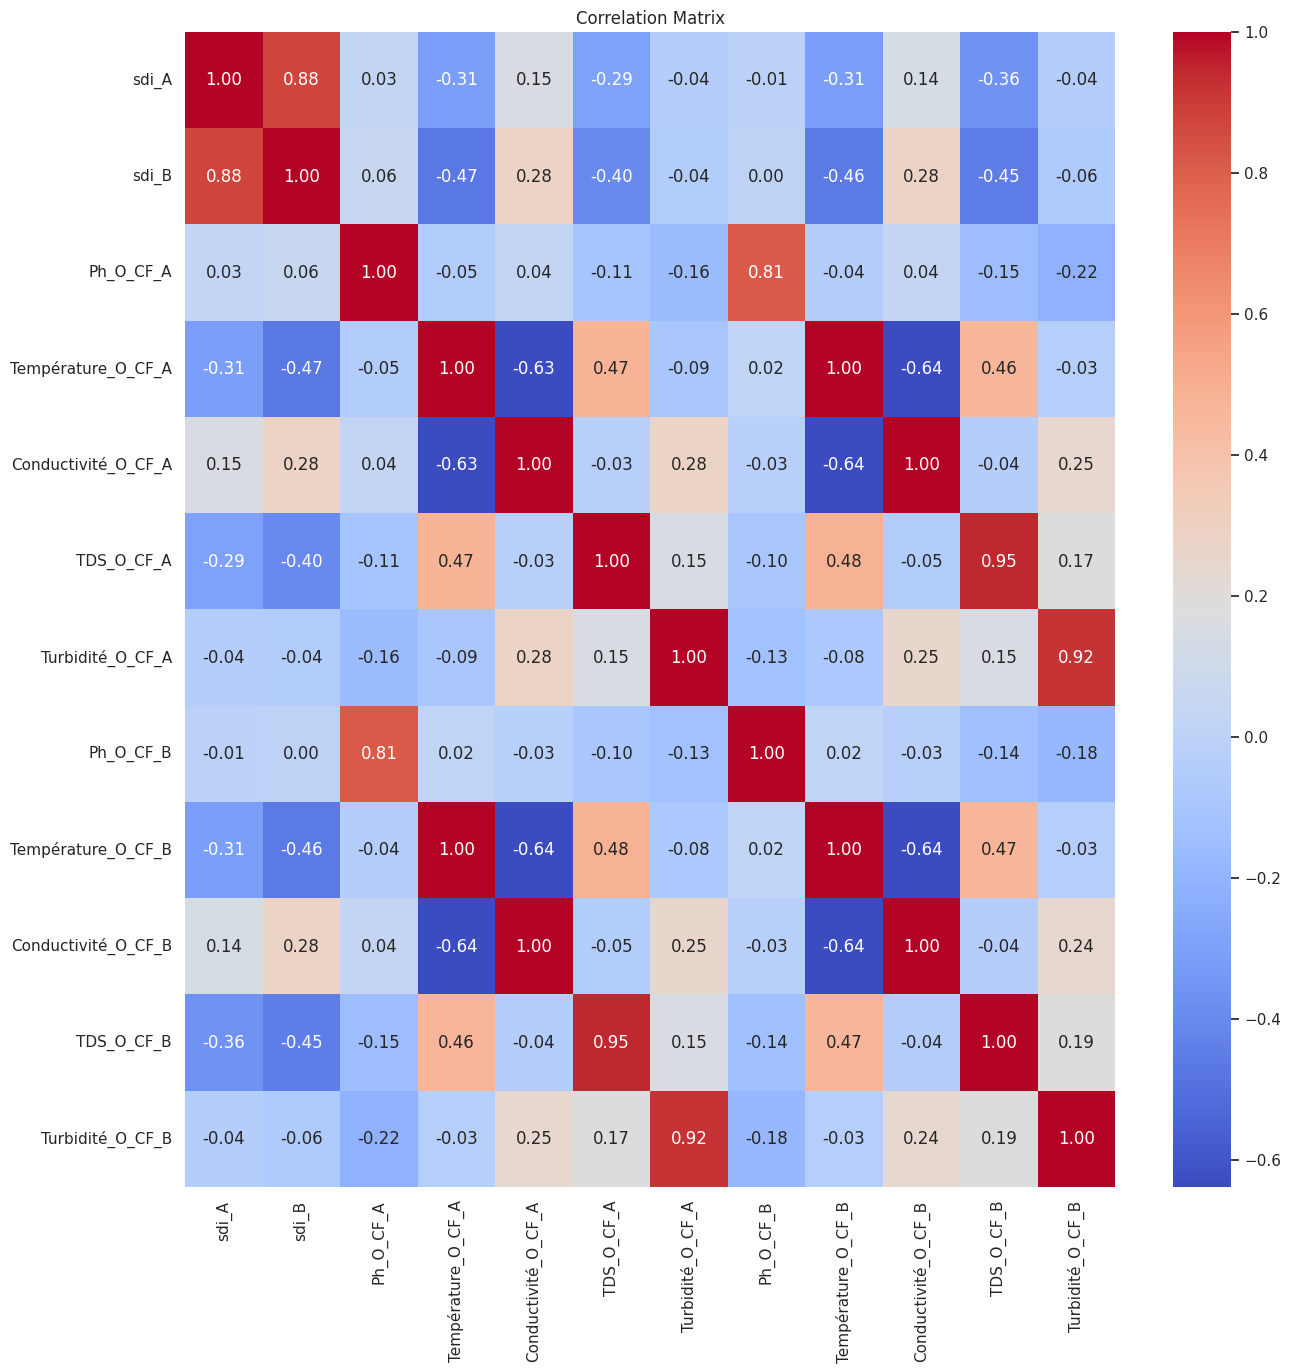

In [44]:
# select only sdi column and the column that include CF in their name
sdi_cf_df = merged_df[['sdi_A', 'sdi_B'] + [col for col in merged_df.columns if 'CF' in col]]
print("Number of rows in the merged dataframe:", len(sdi_cf_df.dropna()))
corr_matrix = sdi_cf_df.corr()
plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')

plt.show()

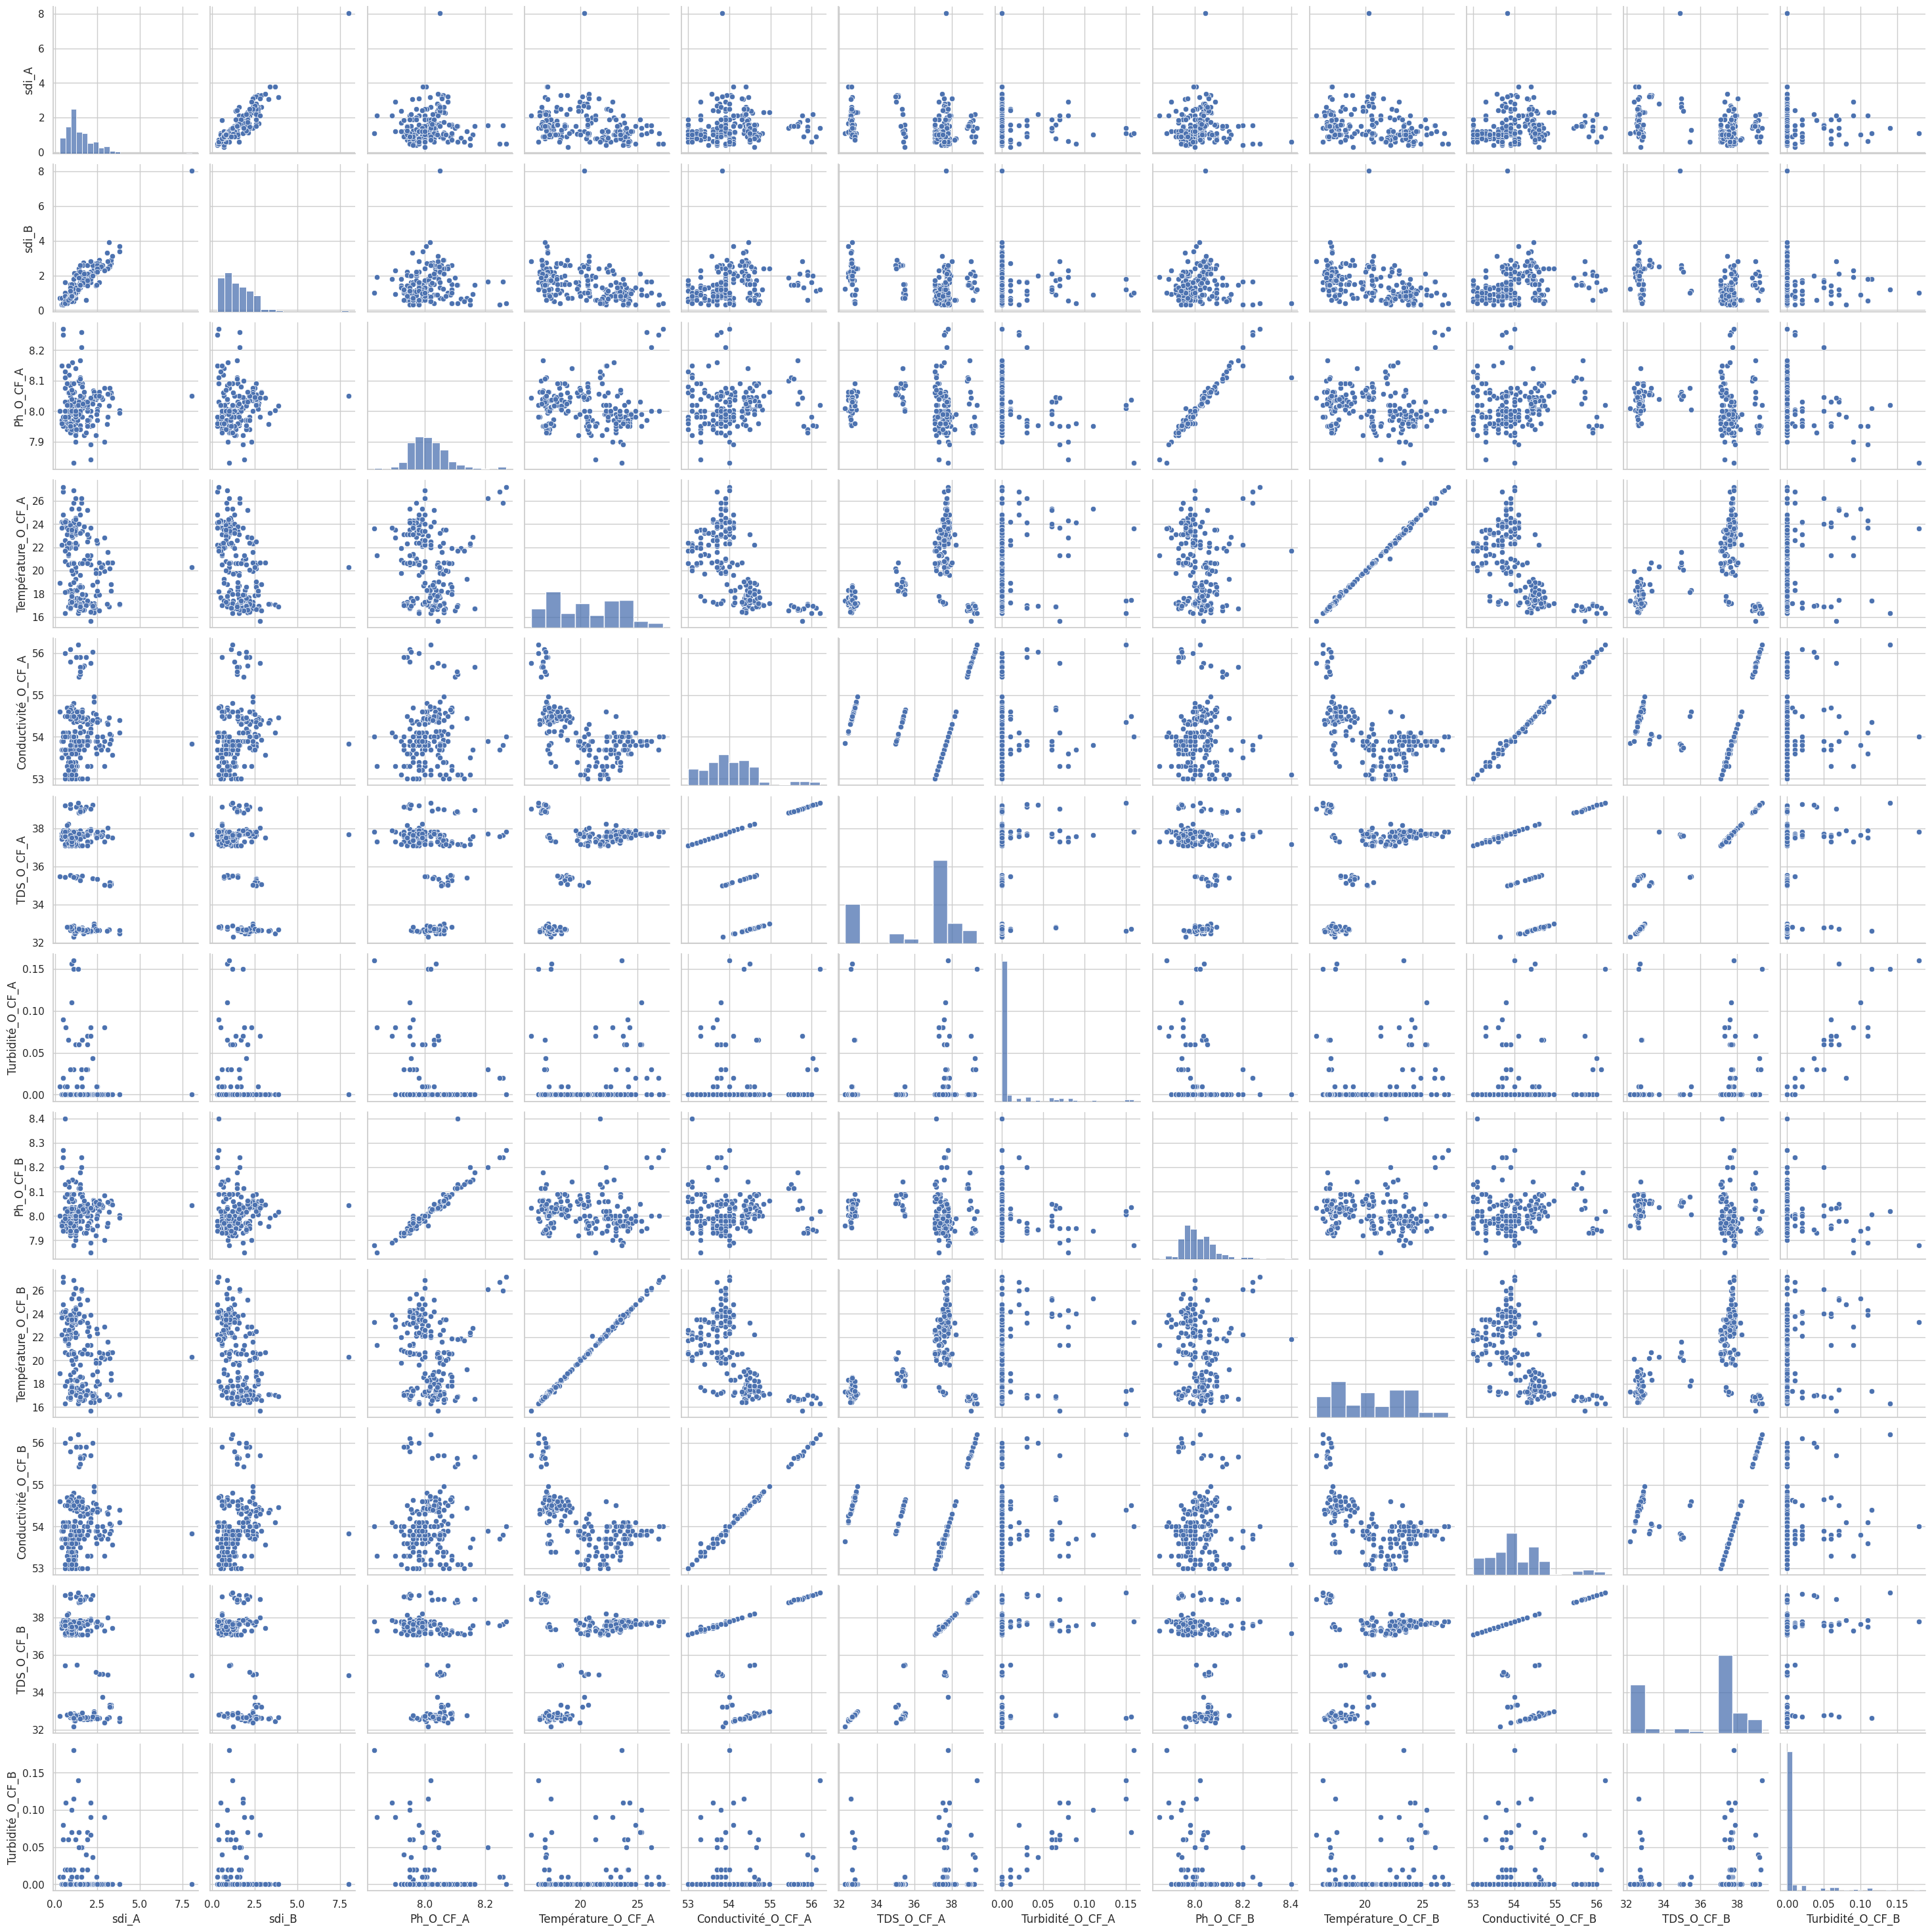

In [30]:
import seaborn as sns

sns.pairplot(sdi_cf_df.dropna())

Number of rows in the merged dataframe: 193


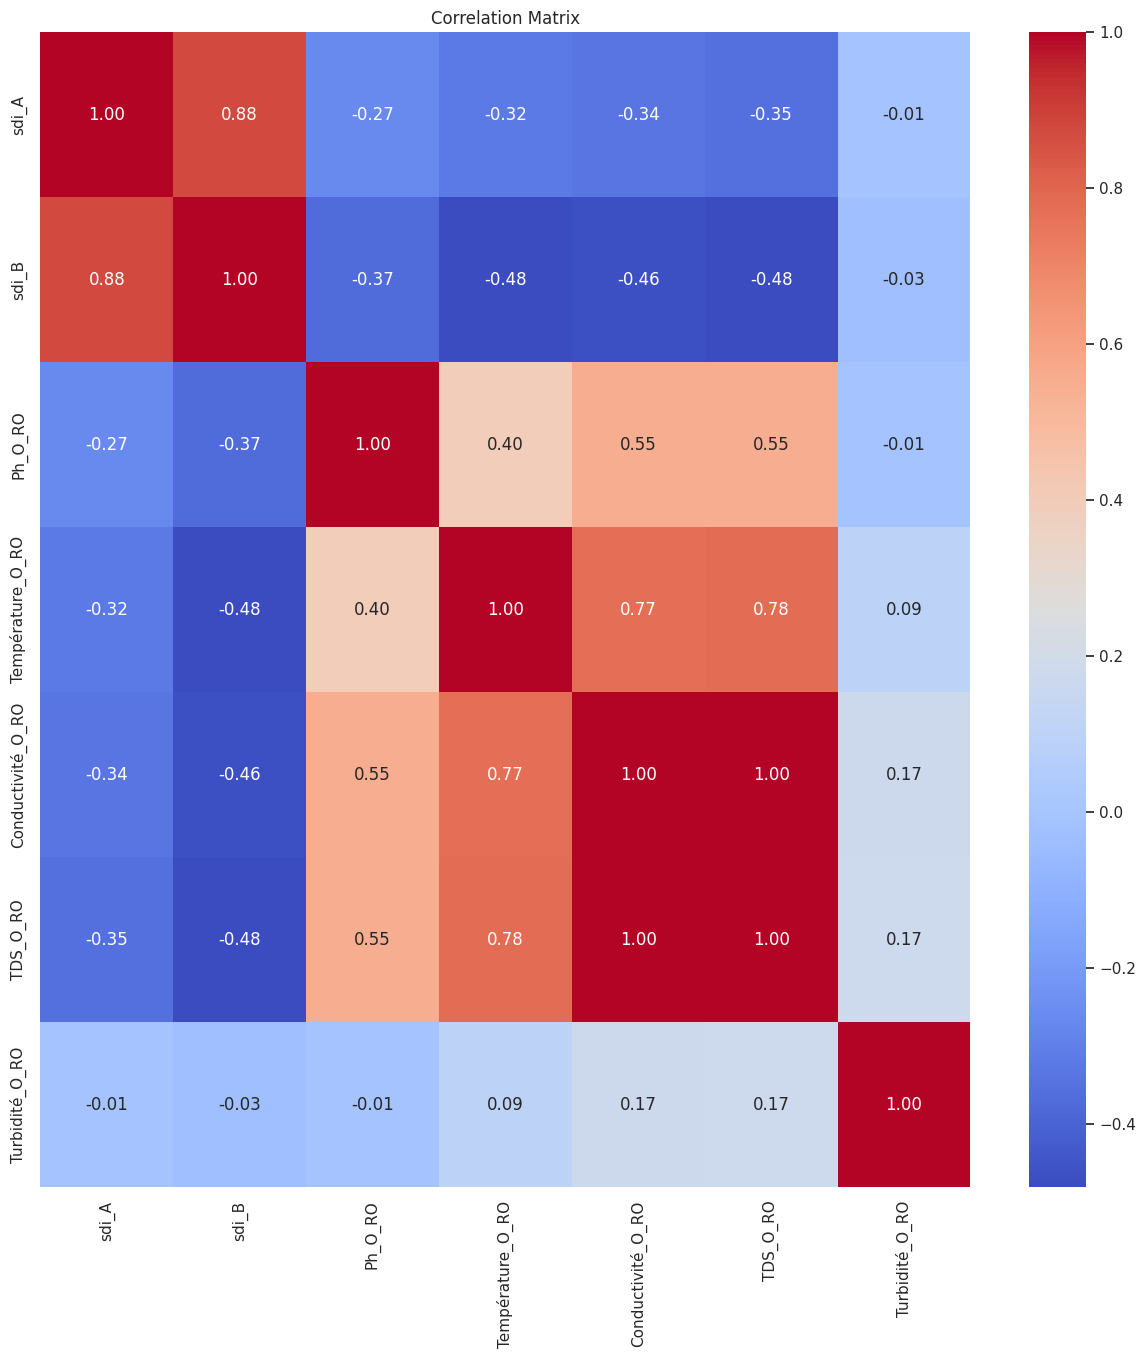

In [45]:
# select only sdi column and the column that include RO in their name
sdi_ro_df = merged_df[['sdi_A', 'sdi_B'] + [col for col in merged_df.columns if 'RO' in col]]
print("Number of rows in the merged dataframe:", len(sdi_ro_df.dropna()))
corr_matrix = sdi_ro_df.corr()
plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')

plt.show()